In [3]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import DBSCAN

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, silhouette_score, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import TruncatedSVD

# Visualization
from wordcloud import WordCloud

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("✅ All libraries imported successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ZAIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ZAIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ZAIN\AppData\Roaming\nltk_data...


✅ All libraries imported successfully!


[nltk_data]   Package omw-1.4 is already up-to-date!


In [4]:
# Load both files
fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

print(" Files loaded!") #verifying
print(f"Fake news rows : {len(fake_df)}") #to print No. of rows
print(f"Real news rows : {len(true_df)}") #to print No. of rows

print(f"\nFake columns: {list(fake_df.columns)}") #printing columns labels
print(f"True columns: {list(true_df.columns)}") #printing columns labels

# Assign labels
fake_df['label'] = 'fake'
true_df['label'] = 'real'

# Merge into one dataframe
df = pd.concat([fake_df, true_df], ignore_index=True)

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n Merged Dataset Shape: {df.shape}")
print(f"\nLabel Distribution:")
print(df['label'].value_counts())
print(f"\nColumns: {list(df.columns)}")
df.head(3)

 Files loaded!
Fake news rows : 23481
Real news rows : 21417

Fake columns: ['title', 'text', 'subject', 'date']
True columns: ['title', 'text', 'subject', 'date']

 Merged Dataset Shape: (44898, 5)

Label Distribution:
label
fake    23481
real    21417
Name: count, dtype: int64

Columns: ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",fake
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",real
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",real


In [5]:
#Inspecting Data
print("=" * 55)
print("COLUMN DATA TYPES")
print("=" * 55)
print(df.dtypes)

print("\n" + "=" * 55)
print("MISSING VALUES")
print("=" * 55)
print(df.isnull().sum())

print("\n" + "=" * 55)
print("LABEL DISTRIBUTION")
print("=" * 55)
print(df['label'].value_counts())
print(f"\nBalance Ratio: {df['label'].value_counts(normalize=True).round(3).to_dict()}")

print("\n" + "=" * 55)
print("SAMPLE TEXT (row 0)")
print("=" * 55)
print(df['text'].iloc[0][:500])

COLUMN DATA TYPES
title      object
text       object
subject    object
date       object
label      object
dtype: object

MISSING VALUES
title      0
text       0
subject    0
date       0
label      0
dtype: int64

LABEL DISTRIBUTION
label
fake    23481
real    21417
Name: count, dtype: int64

Balance Ratio: {'fake': 0.523, 'real': 0.477}

SAMPLE TEXT (row 0)
21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein


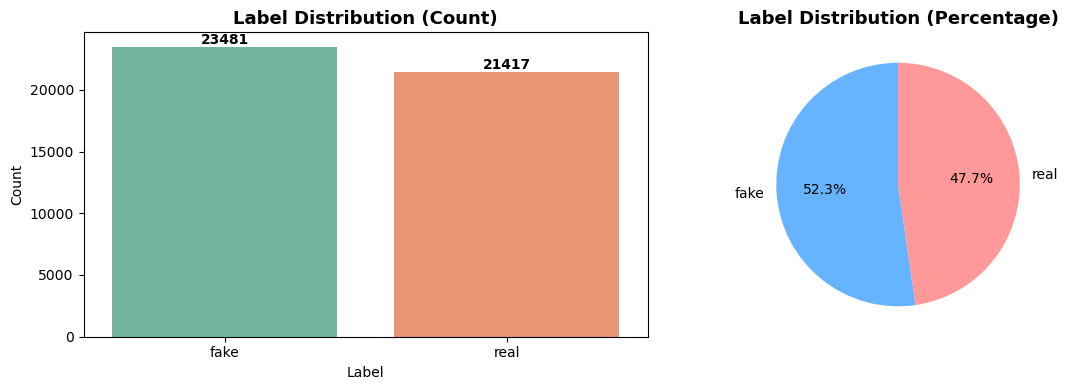

✅ Label distribution plotted.


In [7]:
#EDA — Label Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='label', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Label Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Pie chart
df['label'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'],
                                     startangle=90, ax=axes[1])
axes[1].set_title('Label Distribution (Percentage)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Label distribution plotted.")

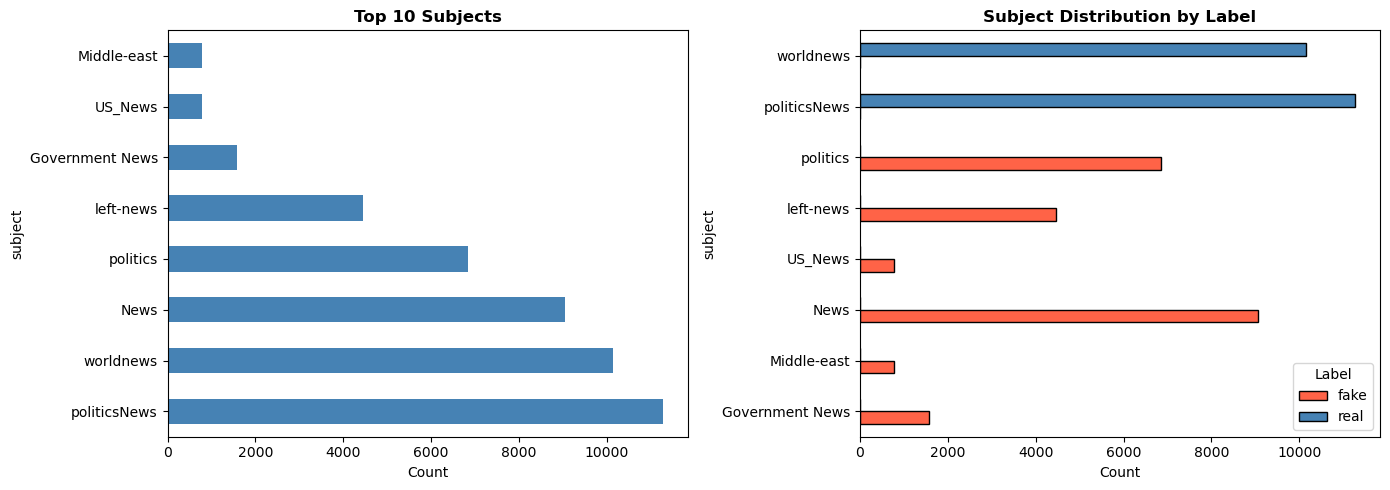

In [8]:
#EDA — Subject Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subject distribution
if 'subject' in df.columns:
    df['subject'].value_counts().head(10).plot(kind='barh', ax=axes[0],
                                                color='steelblue')
    axes[0].set_title('Top 10 Subjects', fontweight='bold')
    axes[0].set_xlabel('Count')

# Subject distribution by label (fake vs real)
if 'subject' in df.columns:
    subject_label = df.groupby(['subject', 'label']).size().unstack(fill_value=0)
    subject_label.plot(kind='barh', ax=axes[1],
                       color=['tomato', 'steelblue'], edgecolor='black')
    axes[1].set_title('Subject Distribution by Label', fontweight='bold')
    axes[1].set_xlabel('Count')
    axes[1].legend(title='Label')

plt.tight_layout()
plt.savefig('category_source.png', dpi=150, bbox_inches='tight')
plt.show()

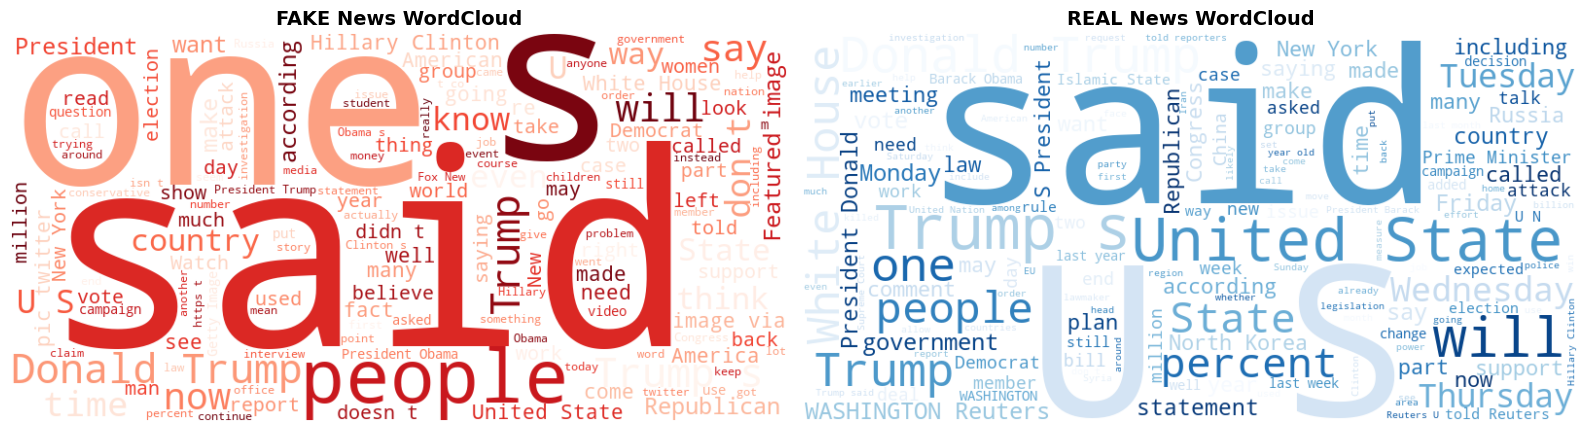

 WordClouds generated.


In [13]:
# EDA — Word Clouds for Fake vs Real News
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, lbl, color, title in zip(
    axes,
    df['label'].unique()[:2],
    ['Reds', 'Blues'],
    ['FAKE News WordCloud', 'REAL News WordCloud']
):
    subset = df[df['label'] == lbl]['text'].dropna().str.cat(sep=' ')
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=color, max_words=150).generate(subset)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print(" WordClouds generated.")

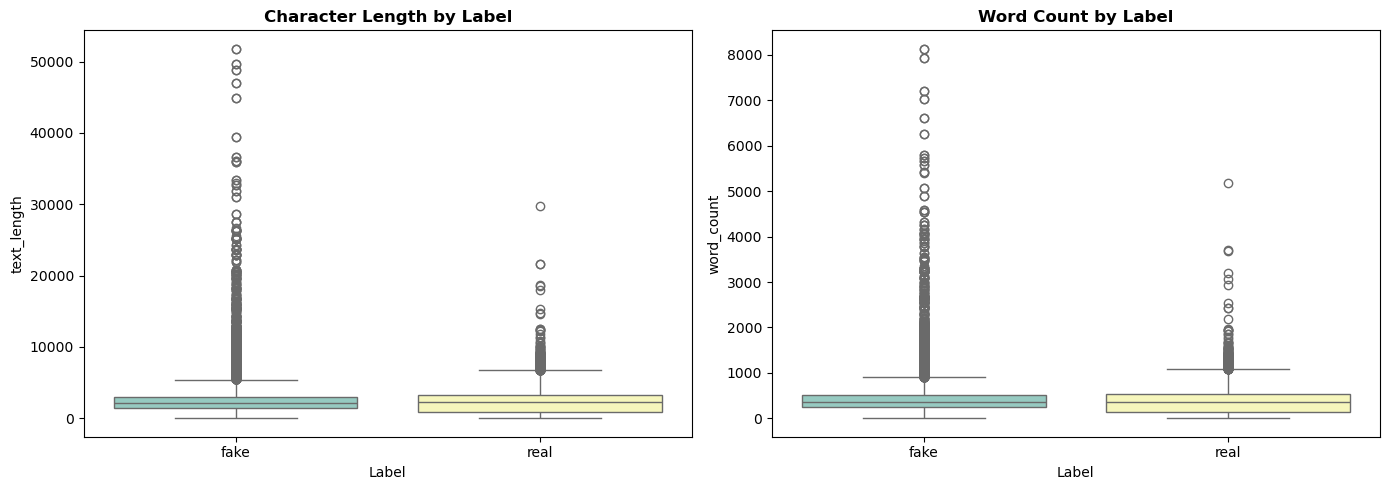


 Text Length Statistics by Label:
         count    mean     std  min    25%    50%    75%     max
label                                                           
fake   23478.0  423.22  408.41  0.0  240.0  363.0  506.0  8135.0
real   21211.0  384.76  273.91  0.0  147.0  359.0  523.0  5172.0


In [14]:
#EDA — Text Length Distribution
df['text_length'] = df['text'].fillna('').apply(len)
df['word_count'] = df['text'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col, ax, title in zip(
    ['text_length', 'word_count'],
    axes,
    ['Character Length by Label', 'Word Count by Label']
):
    sns.boxplot(x='label', y=col, data=df, palette='Set3', ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Label')

plt.tight_layout()
plt.savefig('text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Text Length Statistics by Label:")
print(df.groupby('label')['word_count'].describe().round(2))

In [15]:
#Data Preparation

#Drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"  Duplicates removed: {before - len(df)}")

#Handle missing values
df['title']   = df['title'].fillna('')
df['text']    = df['text'].fillna('')

# 'subject' column exists in this dataset instead of 'category'
if 'subject' in df.columns:
    df['subject'] = df['subject'].fillna('Unknown')
if 'category' not in df.columns:
    df['category'] = df.get('subject', 'Unknown')

print(f" Nulls after cleaning:\n{df.isnull().sum()}")

#Combine title + text
df['combined_text'] = df['title'] + ' ' + df['text']

#Text Cleaning
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)        # remove URLs
    text = re.sub(r'\(reuters\)', '', text)            # remove reuters tag
    text = re.sub(r'[^a-z\s]', '', text)              # letters only
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print("\n Cleaning text... (may take a moment)")
df['cleaned_text'] = df['combined_text'].apply(clean_text)
print(" Text cleaning complete!")
print(f"\nSample cleaned text:\n{df['cleaned_text'].iloc[0][:300]}")

  Duplicates removed: 0
 Nulls after cleaning:
title            0
text             0
subject          0
date             0
label            0
text_length      0
word_count       0
category         0
combined_text    0
cleaned_text     0
dtype: int64

 Cleaning text... (may take a moment)
 Text cleaning complete!

Sample cleaned text:
ben stein call circuit court committed coup dtat constitution century wire say ben stein reputable professor pepperdine university also hollywood fame appearing show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive


In [19]:
# Label Encoding + TF-IDF + 70/15/15 Split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Encode labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])
print(f"  Label Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# TF-IDF — improved settings
print("\n Applying TF-IDF Vectorization...")

texts = df['cleaned_text']
y = df['label_encoded']

# First split raw text
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    texts, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_test_text, X_val_text, y_test, y_val = train_test_split(
    X_temp_text, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Fit TF-IDF ONLY on training data
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
    strip_accents='unicode',
    analyzer='word'
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)
X_val = tfidf.transform(X_val_text)

print(f"Training TF-IDF Shape   : {X_train.shape}")
print(f"Testing TF-IDF Shape    : {X_test.shape}")
print(f"Validation TF-IDF Shape : {X_val.shape}")

print(f"\nTrain size    : {X_train.shape[0]} (70%)")
print(f"Test size     : {X_test.shape[0]} (15%)")
print(f"Validation    : {X_val.shape[0]} (15%)")

import numpy as np

for name, y_split in [
    ('Train', y_train),
    ('Test', y_test),
    ('Validation', y_val)
]:
    vals, counts = np.unique(y_split, return_counts=True)
    print(f"{name}: {dict(zip(le.inverse_transform(vals), counts))}")

  Label Mapping: {'fake': 0, 'real': 1}

 Applying TF-IDF Vectorization...
Training TF-IDF Shape   : (31282, 5000)
Testing TF-IDF Shape    : (6703, 5000)
Validation TF-IDF Shape : (6704, 5000)

Train size    : 31282 (70%)
Test size     : 6703 (15%)
Validation    : 6704 (15%)
Train: {'fake': 16434, 'real': 14848}
Test: {'fake': 3522, 'real': 3181}
Validation: {'fake': 3522, 'real': 3182}


  MODEL 1: MULTINOMIAL NAIVE BAYES

 TEST SET — Classification Report:
              precision    recall  f1-score   support

        fake       0.95      0.96      0.95      3522
        real       0.95      0.94      0.94      3181

    accuracy                           0.95      6703
   macro avg       0.95      0.95      0.95      6703
weighted avg       0.95      0.95      0.95      6703

 VALIDATION SET — Classification Report:
              precision    recall  f1-score   support

        fake       0.95      0.95      0.95      3522
        real       0.95      0.94      0.94      3182

    accuracy                           0.95      6704
   macro avg       0.95      0.95      0.95      6704
weighted avg       0.95      0.95      0.95      6704



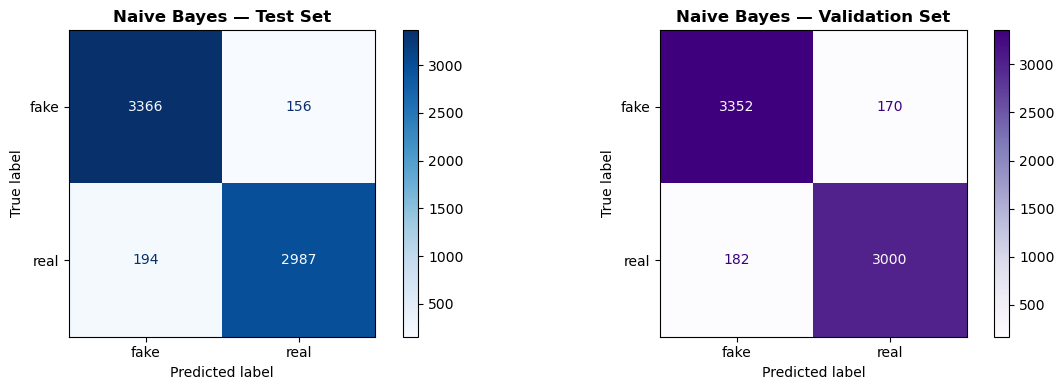


 Test  Accuracy : 0.9478
 Val   Accuracy : 0.9475
 AUC-ROC        : 0.9875


In [20]:
#Model 1 — Multinomial Naive Bayes (with Validation)

print("=" * 60)
print("  MODEL 1: MULTINOMIAL NAIVE BAYES")
print("=" * 60)

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)

# Evaluate on both test and validation
y_pred_nb       = nb_model.predict(X_test)
y_prob_nb       = nb_model.predict_proba(X_test)[:, 1]

y_pred_nb_val   = nb_model.predict(X_val)
y_prob_nb_val   = nb_model.predict_proba(X_val)[:, 1]

print("\n TEST SET — Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

print(" VALIDATION SET — Classification Report:")
print(classification_report(y_val, y_pred_nb_val, target_names=le.classes_))

# Confusion Matrix — Test Set
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb,
    display_labels=le.classes_, cmap='Blues', ax=axes[0])
axes[0].set_title('Naive Bayes — Test Set', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_nb_val,
    display_labels=le.classes_, cmap='Purples', ax=axes[1])
axes[1].set_title('Naive Bayes — Validation Set', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_naive_bayes.png', dpi=150, bbox_inches='tight')
plt.show()

nb_metrics = {
    'Model'    : 'Naive Bayes',
    'Accuracy' : accuracy_score(y_test, y_pred_nb),
    'Precision': precision_score(y_test, y_pred_nb, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_nb, zero_division=0),
    'F1-Score' : f1_score(y_test, y_pred_nb, zero_division=0),
    'AUC-ROC'  : roc_auc_score(y_test, y_prob_nb),
    'Val Accuracy': accuracy_score(y_val, y_pred_nb_val)
}

print(f"\n Test  Accuracy : {nb_metrics['Accuracy']:.4f}")
print(f" Val   Accuracy : {nb_metrics['Val Accuracy']:.4f}")
print(f" AUC-ROC        : {nb_metrics['AUC-ROC']:.4f}")

  MODEL 2: RANDOM FOREST CLASSIFIER
 Training Random Forest... (may take 1-2 minutes)

 TEST SET — Classification Report:
              precision    recall  f1-score   support

        fake       0.99      0.99      0.99      3522
        real       0.98      0.99      0.99      3181

    accuracy                           0.99      6703
   macro avg       0.99      0.99      0.99      6703
weighted avg       0.99      0.99      0.99      6703

 VALIDATION SET — Classification Report:
              precision    recall  f1-score   support

        fake       0.99      0.99      0.99      3522
        real       0.99      0.99      0.99      3182

    accuracy                           0.99      6704
   macro avg       0.99      0.99      0.99      6704
weighted avg       0.99      0.99      0.99      6704



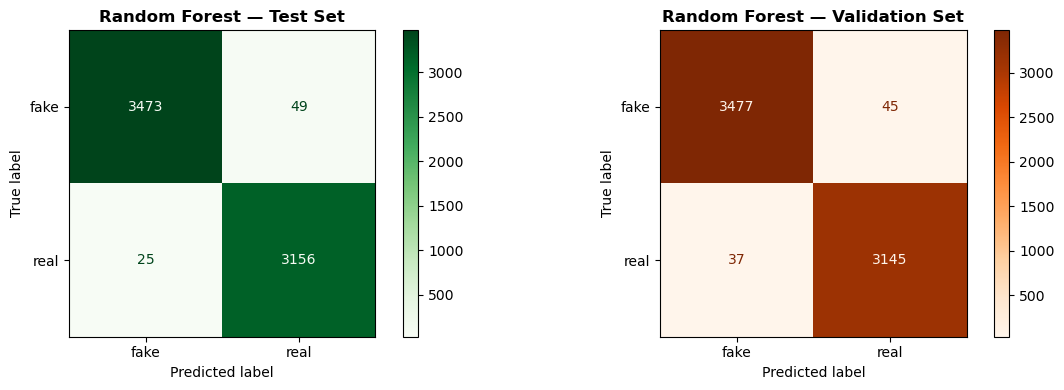


 Test  Accuracy : 0.9890
 Val   Accuracy : 0.9878
 AUC-ROC        : 0.9991


In [21]:
# Model 2 — Random Forest Classifier (with Validation)

print("=" * 60)
print("  MODEL 2: RANDOM FOREST CLASSIFIER")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

print(" Training Random Forest... (may take 1-2 minutes)")
rf_model.fit(X_train, y_train)

y_pred_rf     = rf_model.predict(X_test)
y_prob_rf     = rf_model.predict_proba(X_test)[:, 1]

y_pred_rf_val = rf_model.predict(X_val)
y_prob_rf_val = rf_model.predict_proba(X_val)[:, 1]

print("\n TEST SET — Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

print(" VALIDATION SET — Classification Report:")
print(classification_report(y_val, y_pred_rf_val, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
    display_labels=le.classes_, cmap='Greens', ax=axes[0])
axes[0].set_title('Random Forest — Test Set', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_rf_val,
    display_labels=le.classes_, cmap='Oranges', ax=axes[1])
axes[1].set_title('Random Forest — Validation Set', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

rf_metrics = {
    'Model'       : 'Random Forest',
    'Accuracy'    : accuracy_score(y_test, y_pred_rf),
    'Precision'   : precision_score(y_test, y_pred_rf, zero_division=0),
    'Recall'      : recall_score(y_test, y_pred_rf, zero_division=0),
    'F1-Score'    : f1_score(y_test, y_pred_rf, zero_division=0),
    'AUC-ROC'     : roc_auc_score(y_test, y_prob_rf),
    'Val Accuracy': accuracy_score(y_val, y_pred_rf_val)
}

print(f"\n Test  Accuracy : {rf_metrics['Accuracy']:.4f}")
print(f" Val   Accuracy : {rf_metrics['Val Accuracy']:.4f}")
print(f" AUC-ROC        : {rf_metrics['AUC-ROC']:.4f}")

  MODEL 3: LOGISTIC REGRESSION
 Training Logistic Regression...

Cross Validation F1 Scores:
[0.99109393 0.99009569 0.9873886  0.98874517 0.99074853]

Mean CV F1 Score: 0.9896

 TEST SET — Classification Report:
              precision    recall  f1-score   support

        fake       0.99      0.99      0.99      3522
        real       0.99      0.99      0.99      3181

    accuracy                           0.99      6703
   macro avg       0.99      0.99      0.99      6703
weighted avg       0.99      0.99      0.99      6703

 VALIDATION SET — Classification Report:
              precision    recall  f1-score   support

        fake       0.99      0.99      0.99      3522
        real       0.99      0.99      0.99      3182

    accuracy                           0.99      6704
   macro avg       0.99      0.99      0.99      6704
weighted avg       0.99      0.99      0.99      6704



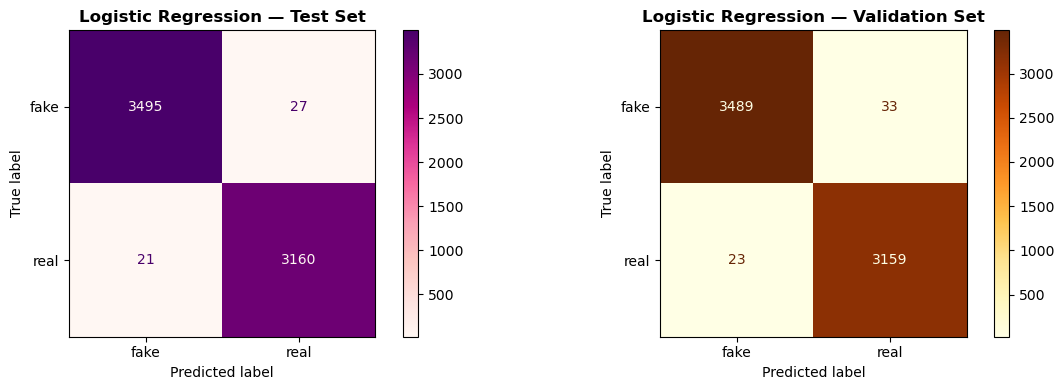


 Test  Accuracy : 0.9928
 Val   Accuracy : 0.9916
 AUC-ROC        : 0.9996


In [22]:
# Model 3 — Logistic Regression (with Validation)

from sklearn.linear_model import LogisticRegression

print("=" * 60)
print("  MODEL 3: LOGISTIC REGRESSION")
print("=" * 60)

lr_model = LogisticRegression(
    C=5.0,                  # regularization strength
    solver='saga',          # best solver for large sparse TF-IDF matrices
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

print(" Training Logistic Regression...")
lr_model.fit(X_train, y_train)

# ── Cross Validation ─────────────────────────────
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("\nCross Validation F1 Scores:")
print(scores)

print(f"\nMean CV F1 Score: {scores.mean():.4f}")

y_pred_lr     = lr_model.predict(X_test)
y_prob_lr     = lr_model.predict_proba(X_test)[:, 1]

y_pred_lr_val = lr_model.predict(X_val)
y_prob_lr_val = lr_model.predict_proba(X_val)[:, 1]

print("\n TEST SET — Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

print(" VALIDATION SET — Classification Report:")
print(classification_report(y_val, y_pred_lr_val, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,
    display_labels=le.classes_, cmap='RdPu', ax=axes[0])
axes[0].set_title('Logistic Regression — Test Set', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_lr_val,
    display_labels=le.classes_, cmap='YlOrBr', ax=axes[1])
axes[1].set_title('Logistic Regression — Validation Set', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

lr_metrics = {
    'Model'       : 'Logistic Regression',
    'Accuracy'    : accuracy_score(y_test, y_pred_lr),
    'Precision'   : precision_score(y_test, y_pred_lr, zero_division=0),
    'Recall'      : recall_score(y_test, y_pred_lr, zero_division=0),
    'F1-Score'    : f1_score(y_test, y_pred_lr, zero_division=0),
    'AUC-ROC'     : roc_auc_score(y_test, y_prob_lr),
    'Val Accuracy': accuracy_score(y_val, y_pred_lr_val)
}

print(f"\n Test  Accuracy : {lr_metrics['Accuracy']:.4f}")
print(f" Val   Accuracy : {lr_metrics['Val Accuracy']:.4f}")
print(f" AUC-ROC        : {lr_metrics['AUC-ROC']:.4f}")

  MODEL 4: SUPPORT VECTOR MACHINE (SVM)
 Training SVM... (may take 1-2 minutes)

 TEST SET — Classification Report:
              precision    recall  f1-score   support

        fake       0.99      1.00      0.99      3522
        real       0.99      0.99      0.99      3181

    accuracy                           0.99      6703
   macro avg       0.99      0.99      0.99      6703
weighted avg       0.99      0.99      0.99      6703

 VALIDATION SET — Classification Report:
              precision    recall  f1-score   support

        fake       0.99      0.99      0.99      3522
        real       0.99      0.99      0.99      3182

    accuracy                           0.99      6704
   macro avg       0.99      0.99      0.99      6704
weighted avg       0.99      0.99      0.99      6704



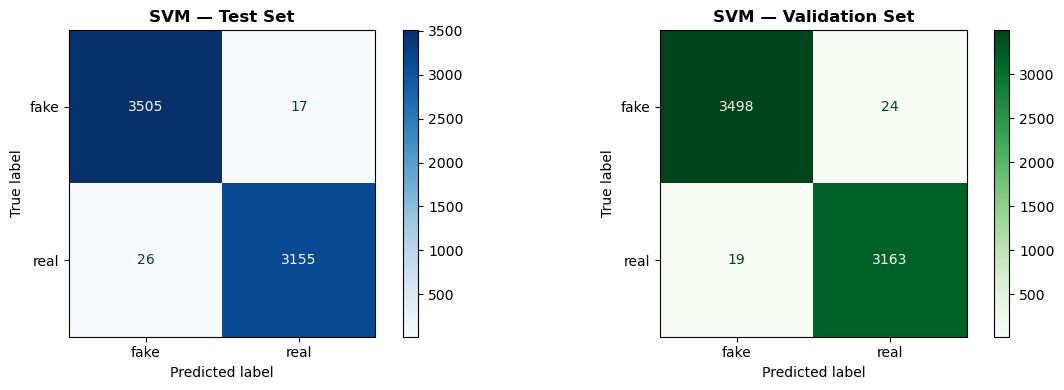


 Test  Accuracy : 0.9936
 Val   Accuracy : 0.9936
 AUC-ROC        : 0.9996


In [25]:
# Model 4 — Support Vector Machine (SVM)

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

print("=" * 60)
print("  MODEL 4: SUPPORT VECTOR MACHINE (SVM)")
print("=" * 60)

# LinearSVC is much faster than SVC on large TF-IDF matrices
# CalibratedClassifierCV wraps it to enable predict_proba for AUC-ROC
svm_base  = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model = CalibratedClassifierCV(svm_base, cv=3)

print(" Training SVM... (may take 1-2 minutes)")
svm_model.fit(X_train, y_train)

y_pred_svm     = svm_model.predict(X_test)
y_prob_svm     = svm_model.predict_proba(X_test)[:, 1]

y_pred_svm_val = svm_model.predict(X_val)
y_prob_svm_val = svm_model.predict_proba(X_val)[:, 1]

print("\n TEST SET — Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

print(" VALIDATION SET — Classification Report:")
print(classification_report(y_val, y_pred_svm_val, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm,
    display_labels=le.classes_, cmap='Blues', ax=axes[0])
axes[0].set_title('SVM — Test Set', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_svm_val,
    display_labels=le.classes_, cmap='Greens', ax=axes[1])
axes[1].set_title('SVM — Validation Set', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_svm.png', dpi=150, bbox_inches='tight')
plt.show()

svm_metrics = {
    'Model'       : 'SVM',
    'Accuracy'    : accuracy_score(y_test, y_pred_svm),
    'Precision'   : precision_score(y_test, y_pred_svm, zero_division=0),
    'Recall'      : recall_score(y_test, y_pred_svm, zero_division=0),
    'F1-Score'    : f1_score(y_test, y_pred_svm, zero_division=0),
    'AUC-ROC'     : roc_auc_score(y_test, y_prob_svm),
    'Val Accuracy': accuracy_score(y_val, y_pred_svm_val)
}

print(f"\n Test  Accuracy : {svm_metrics['Accuracy']:.4f}")
print(f" Val   Accuracy : {svm_metrics['Val Accuracy']:.4f}")
print(f" AUC-ROC        : {svm_metrics['AUC-ROC']:.4f}")


  MODEL 5: K-NEAREST NEIGHBORS (KNN)
 Reducing dimensions for KNN using TruncatedSVD (100 components)...
 Reduced shape : (31282, 100)

 Finding best K value (testing K = 3, 5, 7, 9, 11)...
   K= 3  →  Val Accuracy: 0.9494
   K= 5  →  Val Accuracy: 0.9467
   K= 7  →  Val Accuracy: 0.9497
   K= 9  →  Val Accuracy: 0.9482
   K=11  →  Val Accuracy: 0.9463

 Best K = 7  (Val Accuracy: 0.9497)


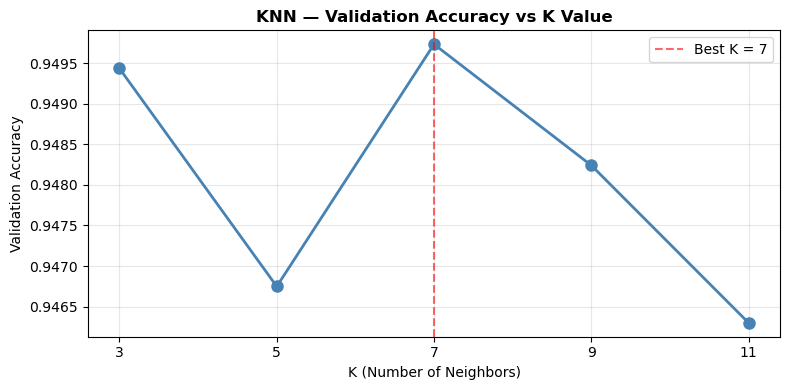


 TEST SET — Classification Report:
              precision    recall  f1-score   support

        fake       0.97      0.93      0.95      3522
        real       0.93      0.96      0.94      3181

    accuracy                           0.95      6703
   macro avg       0.95      0.95      0.95      6703
weighted avg       0.95      0.95      0.95      6703

 VALIDATION SET — Classification Report:
              precision    recall  f1-score   support

        fake       0.97      0.93      0.95      3522
        real       0.93      0.97      0.95      3182

    accuracy                           0.95      6704
   macro avg       0.95      0.95      0.95      6704
weighted avg       0.95      0.95      0.95      6704



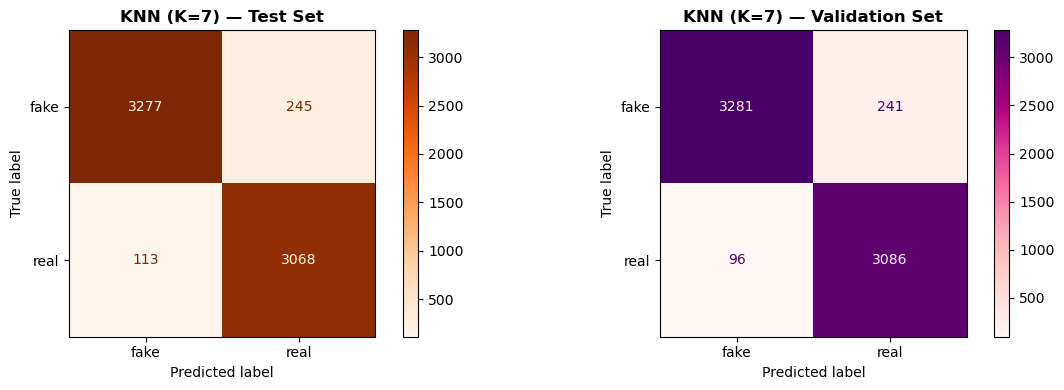


 Test  Accuracy : 0.9466
 Val   Accuracy : 0.9497
 AUC-ROC        : 0.9862


In [26]:
# Model 5 — K-Nearest Neighbors (KNN)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import TruncatedSVD
import scipy.sparse as sp

print("=" * 60)
print("  MODEL 5: K-NEAREST NEIGHBORS (KNN)")
print("=" * 60)

# ── Important: KNN cannot work efficiently on 50,000-dim sparse TF-IDF ──
# We reduce dimensions to 100 using TruncatedSVD (LSA) first
print(" Reducing dimensions for KNN using TruncatedSVD (100 components)...")
svd_knn = TruncatedSVD(n_components=100, random_state=42)

X_train_knn = svd_knn.fit_transform(X_train)
X_test_knn  = svd_knn.transform(X_test)
X_val_knn   = svd_knn.transform(X_val)

print(f" Reduced shape : {X_train_knn.shape}")

# ── Find best K using validation set ───────────────────────────────
print("\n Finding best K value (testing K = 3, 5, 7, 9, 11)...")
k_values   = [3, 5, 7, 9, 11]
val_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    knn_temp.fit(X_train_knn, y_train)
    val_acc = accuracy_score(y_val, knn_temp.predict(X_val_knn))
    val_scores.append(val_acc)
    print(f"   K={k:2d}  →  Val Accuracy: {val_acc:.4f}")

best_k = k_values[val_scores.index(max(val_scores))]
print(f"\n Best K = {best_k}  (Val Accuracy: {max(val_scores):.4f})")

# Plot K vs Accuracy
plt.figure(figsize=(8, 4))
plt.plot(k_values, val_scores, marker='o', color='steelblue',
         linewidth=2, markersize=8)
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.6,
            label=f'Best K = {best_k}')
plt.title('KNN — Validation Accuracy vs K Value', fontweight='bold')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Validation Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Train final KNN with best K ────────────────────────────────────
knn_model = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', n_jobs=-1)
knn_model.fit(X_train_knn, y_train)

y_pred_knn     = knn_model.predict(X_test_knn)
y_prob_knn     = knn_model.predict_proba(X_test_knn)[:, 1]

y_pred_knn_val = knn_model.predict(X_val_knn)
y_prob_knn_val = knn_model.predict_proba(X_val_knn)[:, 1]

print("\n TEST SET — Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

print(" VALIDATION SET — Classification Report:")
print(classification_report(y_val, y_pred_knn_val, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn,
    display_labels=le.classes_, cmap='Oranges', ax=axes[0])
axes[0].set_title(f'KNN (K={best_k}) — Test Set', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_knn_val,
    display_labels=le.classes_, cmap='RdPu', ax=axes[1])
axes[1].set_title(f'KNN (K={best_k}) — Validation Set', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_knn.png', dpi=150, bbox_inches='tight')
plt.show()

knn_metrics = {
    'Model'       : 'KNN',
    'Accuracy'    : accuracy_score(y_test, y_pred_knn),
    'Precision'   : precision_score(y_test, y_pred_knn, zero_division=0),
    'Recall'      : recall_score(y_test, y_pred_knn, zero_division=0),
    'F1-Score'    : f1_score(y_test, y_pred_knn, zero_division=0),
    'AUC-ROC'     : roc_auc_score(y_test, y_prob_knn),
    'Val Accuracy': accuracy_score(y_val, y_pred_knn_val)
}

print(f"\n Test  Accuracy : {knn_metrics['Accuracy']:.4f}")
print(f" Val   Accuracy : {knn_metrics['Val Accuracy']:.4f}")
print(f" AUC-ROC        : {knn_metrics['AUC-ROC']:.4f}")

In [27]:
# DBSCAN Clustering (Unsupervised)

print("=" * 55)
print("DBSCAN CLUSTERING")
print("=" * 55)

# Reduce dimensions for DBSCAN (TF-IDF is too sparse)
print("⏳ Reducing dimensions with TruncatedSVD (LSA)...")
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X)
print(f" Reduced shape: {X_reduced.shape}")

# Apply DBSCAN
print("\n⏳ Running DBSCAN...")
dbscan = DBSCAN(eps=2.5, min_samples=5, metric='euclidean', n_jobs=-1)
cluster_labels = dbscan.fit_predict(X_reduced)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = list(cluster_labels).count(-1)

print(f"\n Number of Clusters Found : {n_clusters}")
print(f" Noise Points (label = -1) : {n_noise}")

# Silhouette Score (exclude noise)
mask = cluster_labels != -1
if len(set(cluster_labels[mask])) > 1:
    sil_score = silhouette_score(X_reduced[mask], cluster_labels[mask])
    print(f" Silhouette Score          : {sil_score:.4f}")
else:
    sil_score = None
    print("  Not enough clusters for Silhouette Score.")

# Visualize clusters (2D projection)
svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_2d   = svd_2d.fit_transform(X_reduced)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                       c=cluster_labels, cmap='tab20',
                       s=5, alpha=0.6)
plt.colorbar(scatter, label='Cluster Label')
plt.title('DBSCAN Clustering of News Articles\n(2D via TruncatedSVD)', fontweight='bold')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

DBSCAN CLUSTERING
⏳ Reducing dimensions with TruncatedSVD (LSA)...


NameError: name 'X' is not defined

  FULL MODEL COMPARISON — TEST SET
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC  Val Accuracy
Model                                                                            
Naive Bayes            0.9478     0.9504  0.9390    0.9447   0.9875        0.9475
Random Forest          0.9890     0.9847  0.9921    0.9884   0.9991        0.9878
Logistic Regression    0.9928     0.9915  0.9934    0.9925   0.9996        0.9916
SVM                    0.9936     0.9946  0.9918    0.9932   0.9996        0.9936
KNN                    0.9466     0.9260  0.9645    0.9449   0.9862        0.9497


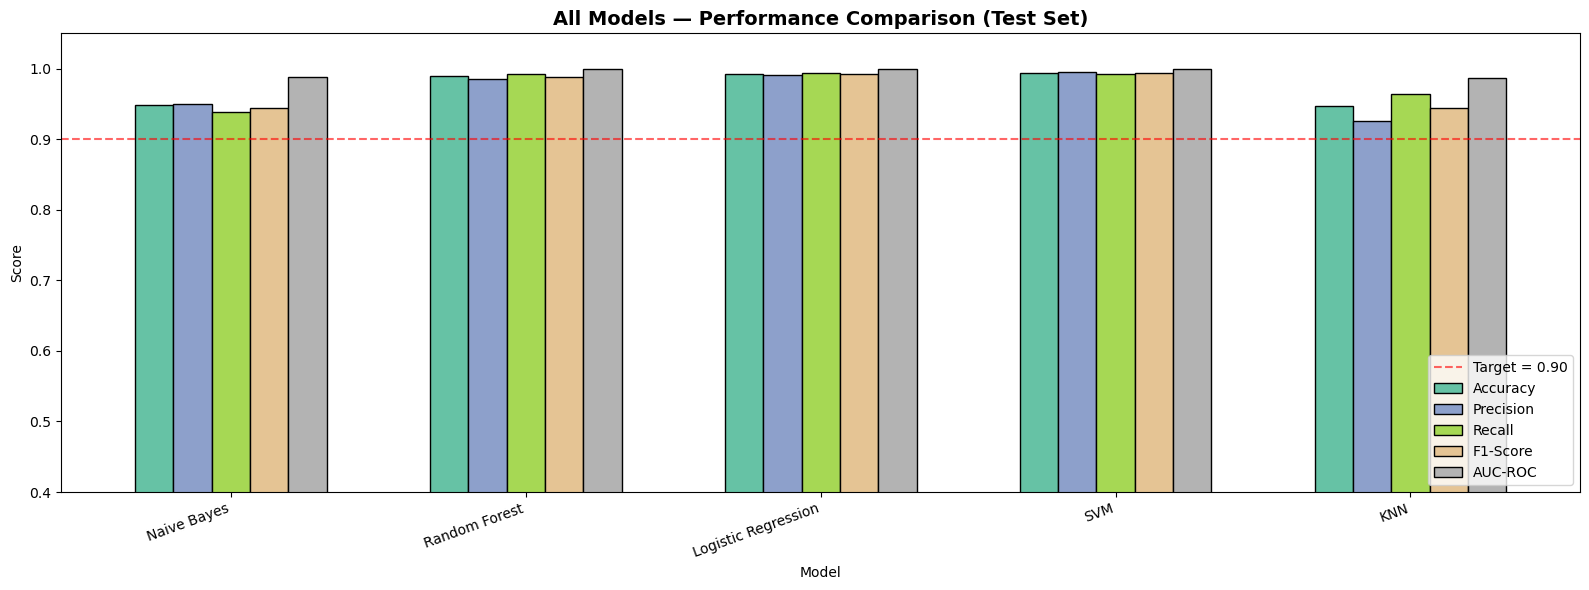

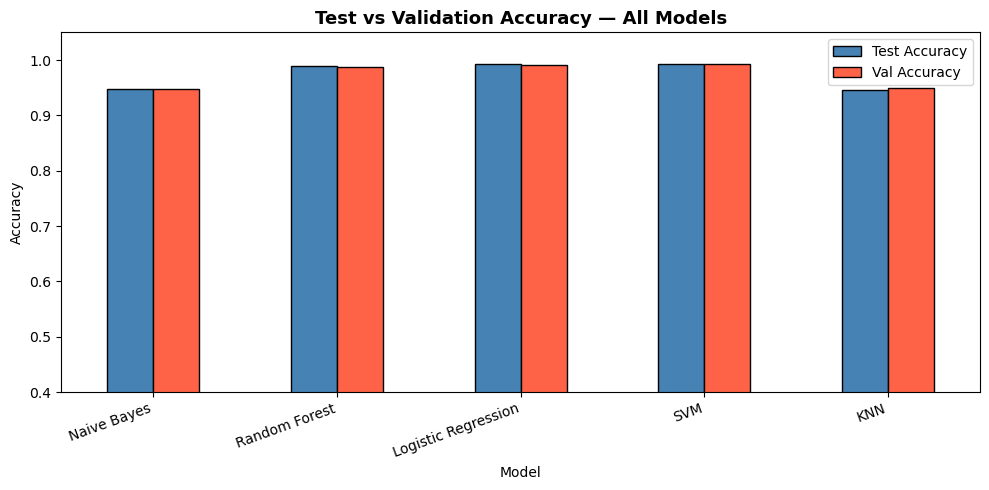

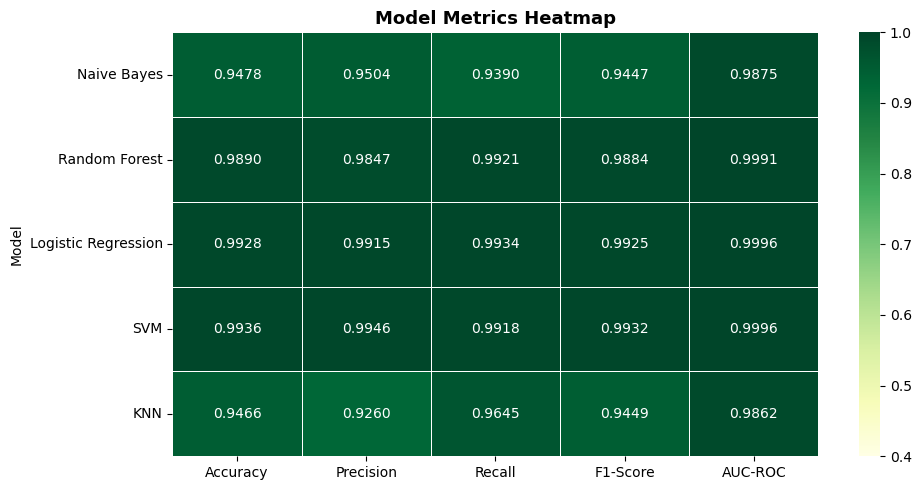


 Best Model     : SVM
   F1-Score      : 0.9932
   AUC-ROC       : 0.9996
   Val Accuracy  : 0.9936

 DBSCAN Summary:


NameError: name 'n_clusters' is not defined

In [28]:
# Evaluation — Compare All 6 Models

results_df = pd.DataFrame([nb_metrics, rf_metrics, lr_metrics,
                            svm_metrics, knn_metrics])
results_df = results_df.set_index('Model')

print("=" * 75)
print("  FULL MODEL COMPARISON — TEST SET")
print("=" * 75)
print(results_df.round(4).to_string())

# ── Bar Chart — All Metrics ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
plot_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
results_df[plot_cols].plot(kind='bar', ax=ax, colormap='Set2',
                            edgecolor='black', width=0.65)
ax.set_title('All Models — Performance Comparison (Test Set)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0.4, 1.05)
ax.set_xticklabels(results_df.index, rotation=20, ha='right')
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.6, label='Target = 0.90')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Test vs Validation Accuracy ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
results_df[['Accuracy', 'Val Accuracy']].plot(
    kind='bar', ax=ax, color=['steelblue', 'tomato'],
    edgecolor='black', width=0.5)
ax.set_title('Test vs Validation Accuracy — All Models',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.4, 1.05)
ax.set_xticklabels(results_df.index, rotation=20, ha='right')
ax.legend(['Test Accuracy', 'Val Accuracy'])
plt.tight_layout()
plt.savefig('test_vs_val_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Heatmap of all metrics ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(results_df[plot_cols].astype(float),
            annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, ax=ax, vmin=0.4, vmax=1.0)
ax.set_title('Model Metrics Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Best Model ─────────────────────────────────────────────────────
best_model = results_df['F1-Score'].idxmax()
print(f"\n Best Model     : {best_model}")
print(f"   F1-Score      : {results_df.loc[best_model, 'F1-Score']:.4f}")
print(f"   AUC-ROC       : {results_df.loc[best_model, 'AUC-ROC']:.4f}")
print(f"   Val Accuracy  : {results_df.loc[best_model, 'Val Accuracy']:.4f}")

# ── DBSCAN Summary ─────────────────────────────────────────────────
print(f"\n DBSCAN Summary:")
print(f"   Clusters Found   : {n_clusters}")
print(f"   Noise Points     : {n_noise}")
if sil_score:
    print(f"   Silhouette Score : {sil_score:.4f}")

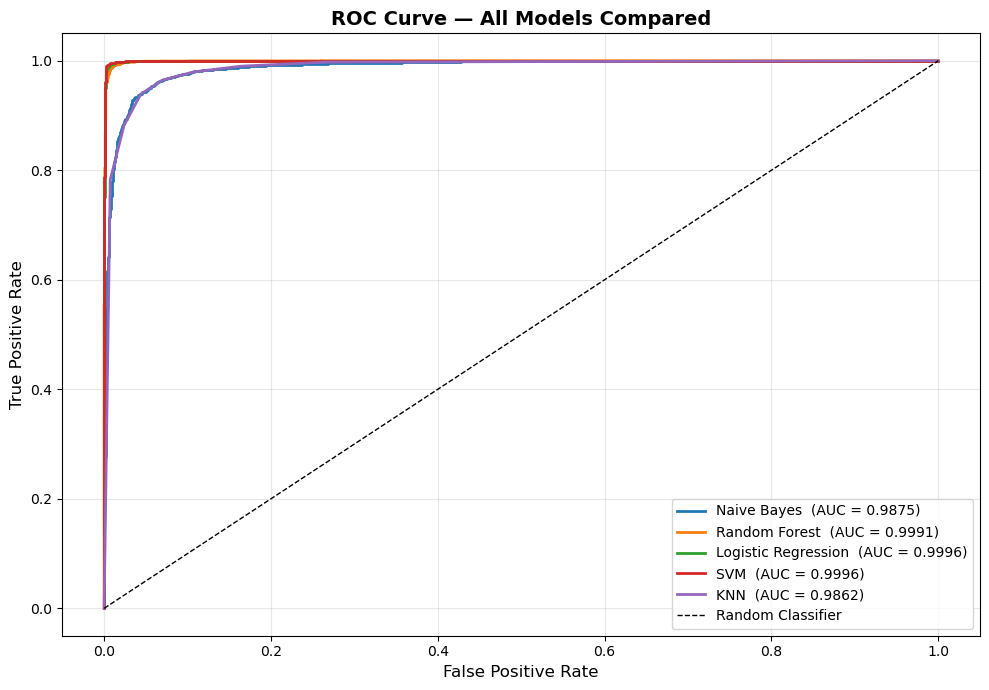

In [29]:
# ROC Curve — All 5 Classification Models

from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))

for name, y_prob in [
    ('Naive Bayes',         y_prob_nb),
    ('Random Forest',       y_prob_rf),
    ('Logistic Regression', y_prob_lr),
    ('SVM',                 y_prob_svm),
    ('KNN',                 y_prob_knn),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name}  (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models Compared', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
from sklearn.ensemble import VotingClassifier

ensemble_model = VotingClassifier(
    estimators=[
        ('nb', nb_model),
        ('lr', lr_model),
        ('rf', rf_model),
        ('svm', svm_model)
    ],
    voting='soft'
)

ensemble_model.fit(X_train, y_train)
y_pred_ensemble = ensemble_model.predict(X_test)
y_prob_ensemble = ensemble_model.predict_proba(X_test)[:, 1]
print("done")

done


In [34]:
print(type(ensemble_model))
print(type(tfidf))
print(type(le))

import joblib

joblib.dump(ensemble_model, "ensemble_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(le, "label_encoder.pkl")

print("✅ Models saved successfully!")

<class 'sklearn.ensemble._voting.VotingClassifier'>
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
<class 'sklearn.preprocessing._label.LabelEncoder'>
✅ Models saved successfully!


In [37]:
!pip freeze > requirements.txt
print("done")

done
